# Demand response and identification

How does room occupancy respond to the **real** room rate, by category?

1. Naive regressions: log-log / +lag / percentage-point / bounded (logit).
2. **Endogeneity** — hotels raise real prices *into* strong demand, so the
   naive slope is an association, biased toward zero / positive.
3. Identification attempts: year-on-year differencing; a relative-price panel
   with month + category fixed effects; 2SLS with an operating-cost instrument.
   Each is scrutinised for relevance, over-identification and weak-IV.
4. **Verdict:** carry a *causal* elasticity into the policy work only if an
   endogeneity-breaking design gives a negative, significant, sane estimate
   with a strong first stage. Otherwise the elasticity is **associational** and
   the policy sims are run across a $\beta$ *scenario grid*.

Sample: main analysis sample (COVID held out).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from linearmodels.iv import IV2SLS
from linearmodels.panel import PanelOLS

SRC = Path.cwd() / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog

LOG = AuditLog("06_demand")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3, "axes.axisbelow": True})

df = pd.read_parquet(C.P_ANALYSIS)
df = df[(df.in_sample == 1)].sort_values(["hotel_category", "date"]).copy()
CORE = C.CORE_CATEGORIES
ALLc = C.MODEL_CATEGORIES
LAB = C.CATEGORY_LABELS
MON = [f"m{m:02d}" for m in range(2, 13)]
HAC = dict(cov_type="HAC", cov_kwds={"maxlags": 6})

# operating-cost instrument: GBA "housing, water, electricity, gas…" division
# (INDEC "Vivienda, agua, electricidad, gas y otros combustibles") relative to
# the headline CPI (rents + utilities = hotel operating-cost pressure).
craw = pd.read_parquet(C.P_LOADED_DIR / "cpi.parquet")
craw = craw[(craw.src_sheet == "index_national") & (craw.region == "gba")]
piv = craw.pivot_table(index="date", columns="series", values="value")
cost = pd.DataFrame({"rel_vivienda": np.log(
    piv["Vivienda, agua, electricidad, gas y otros combustibles"] / piv["Nivel general"])}).reset_index()
df = df.merge(cost, on="date", how="left")

g = df.groupby("hotel_category", group_keys=False)
df["ln_occ"] = np.log(df["room_occupancy"])
df["ln_rr"] = np.log(df["real_rate_gba"])
df["ln_rr_l1"] = g["ln_rr"].apply(lambda s: s.shift(1))
df["logit_occ"] = np.log((df["room_occupancy"] / 100) / (1 - df["room_occupancy"] / 100))
df["infl"] = df["infl_mom_gba"]
df["ln_occ_yoy"] = g["ln_occ"].apply(lambda s: s.diff(12))
df["ln_rr_yoy"] = g["ln_rr"].apply(lambda s: s.diff(12))
df["rel_vivienda_l1"] = g["rel_vivienda"].apply(lambda s: s.shift(1))
df["rel_vivienda_l2"] = g["rel_vivienda"].apply(lambda s: s.shift(2))

## 1 · Naive elasticity — four specifications  (Table 4)

In [2]:
def run(y, s, regs):
    d = s.dropna(subset=[y] + regs)
    return sm.OLS(d[y], sm.add_constant(d[regs + MON].astype(float))).fit(**HAC)


rows = []
for cat in ALLc:
    s = df[df.hotel_category == cat].copy()
    s["t_"] = s["t"]
    for name, (y, regs, key) in {
        "loglog": ("ln_occ", ["ln_rr", "infl", "t_"], "ln_rr"),
        "loglog_lag": ("ln_occ", ["ln_rr", "ln_rr_l1", "infl", "t_"], "ln_rr"),
        "levels_pp": ("room_occupancy", ["real_rate_gba", "infl", "t_"], "real_rate_gba"),
        "logit": ("logit_occ", ["ln_rr", "infl", "t_"], "ln_rr"),
    }.items():
        m = run(y, s, regs)
        rows.append(dict(hotel_category=cat, label=LAB[cat], spec=name,
                         beta=round(float(m.params[key]), 3),
                         se=round(float(m.bse[key]), 3),
                         t=round(float(m.tvalues[key]), 2), n=int(m.nobs)))
tab4 = pd.DataFrame(rows)
tab4.to_csv(C.OUT_TAB / "table4_elasticity.csv", index=False)
LOG.log("write", "table4_elasticity.csv", len(tab4))
tab4.pivot_table(index=["hotel_category", "label"], columns="spec",
                 values=["beta", "t"]).round(3)

  [06_demand] write                  table4_elasticity.csv                  24  


beta                                  t        \
spec                       levels_pp  logit loglog loglog_lag levels_pp logit   
hotel_category label                                                            
apart          Apart-hotel     0.016  0.746  0.340      0.205      2.26  1.86   
boutique       Boutique        0.003  0.306  0.124      0.356      0.84  0.81   
stars_1_2      1-2 star        0.077  1.788  0.832      0.603      5.06  4.95   
stars_3        3 star          0.011  0.332  0.115      0.283      0.75  0.65   
stars_4        4 star          0.012  0.634  0.275      0.623      1.76  1.89   
stars_5        5 star          0.002  0.258  0.127      0.245      0.71  0.83   

                                              
spec                       loglog loglog_lag  
hotel_category label                          
apart          Apart-hotel   2.17       1.52  
boutique       Boutique      0.90       1.88  
stars_1_2      1-2 star      4.92       3.30  
stars_3        3 star        0.60       1.59  
stars_4        4 star        1.93       3.66  
stars_5        5 star        0.92       1.17

## 2 · Endogeneity — why the naive $\beta$ is an association, not a demand elasticity

* **Reverse causality / dynamic pricing.** Hotels raise real rates *because*
  they expect strong demand (holidays, events, favourable exchange-rate windows
  for inbound tourists) → price and occupancy move up together → $\beta$ biased up.
* **Omitted demand shocks.** Exchange-rate competitiveness, regional
  (Brazilian) demand cycles, big events — correlated with both, not captured by
  month dummies (the tourist calendar also shifts year to year).
* **Capacity changes.** Entry / exit / refurbishment move the occupancy
  denominator and the pricing environment; capacity here is only quarterly.
* **Inflation itself.** In this sample high-inflation months coincide with
  high-season, high-demand months (notebook 05 §3).

A credible causal reading needs a supply/cost instrument for the real rate.

## 3 · Identification attempts

### A · Year-on-year differences (kills fixed monthly seasonality)

In [3]:
rowsA = []
for cat in ALLc:
    s = df[df.hotel_category == cat].dropna(subset=["ln_occ_yoy", "ln_rr_yoy", "infl"])
    if len(s) < 20:
        continue
    m = sm.OLS(s["ln_occ_yoy"], sm.add_constant(s[["ln_rr_yoy", "infl", "t"]].astype(float))
               ).fit(cov_type="HAC", cov_kwds={"maxlags": 18})
    rowsA.append(dict(strategy="A_yoy_diff", hotel_category=cat, label=LAB[cat],
                      beta=round(m.params["ln_rr_yoy"], 3), se=round(m.bse["ln_rr_yoy"], 3),
                      t=round(m.tvalues["ln_rr_yoy"], 2), n=int(m.nobs),
                      first_stage_F=np.nan, overid_p=np.nan))
resA = pd.DataFrame(rowsA)
resA

,strategy,hotel_category,label,beta,se,t,n,first_stage_F,overid_p
0,A_yoy_diff,stars_1_2,1-2 star,-0.038,0.216,-0.18,35,NaN,NaN
1,A_yoy_diff,stars_3,3 star,0.131,0.097,1.35,59,NaN,NaN
2,A_yoy_diff,stars_4,4 star,0.402,0.055,7.34,59,NaN,NaN
3,A_yoy_diff,stars_5,5 star,0.171,0.185,0.92,59,NaN,NaN
4,A_yoy_diff,apart,Apart-hotel,0.656,0.052,12.69,59,NaN,NaN
5,A_yoy_diff,boutique,Boutique,0.421,0.117,3.60,59,NaN,NaN


### B · Relative-price panel — month FE + category FE  (headline)

`ln_occ` and `ln_rr` demeaned across the four star tiers each month, then
PanelOLS with entity (category) and time (month) effects, clustered SEs. Time
effects absorb **every** city-wide demand shock; $\beta$ is the within-month
cross-tier relationship.

In [4]:
p = df[df.hotel_category.isin(CORE)].copy()
mm = p.groupby("date")[["ln_occ", "ln_rr"]].transform("mean")
p["ln_occ_dev"] = p["ln_occ"] - mm["ln_occ"]
p["ln_rr_dev"] = p["ln_rr"] - mm["ln_rr"]
p = p.dropna(subset=["ln_occ_dev", "ln_rr_dev"]).set_index(["hotel_category", "date"])
mB = PanelOLS.from_formula("ln_occ_dev ~ ln_rr_dev + EntityEffects + TimeEffects",
                           data=p).fit(cov_type="clustered", cluster_entity=True)
print(mB.summary.tables[1])
resB = pd.DataFrame([dict(strategy="B_relative_price_FE", hotel_category="POOLED",
                          label="4 star tiers", beta=round(mB.params["ln_rr_dev"], 3),
                          se=round(mB.std_errors["ln_rr_dev"], 3),
                          t=round(mB.tstats["ln_rr_dev"], 2), n=int(mB.nobs),
                          first_stage_F=np.nan, overid_p=np.nan)])
resB

                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
ln_rr_dev      0.0739     0.0193     3.8371     0.0002      0.0359      0.1119


,strategy,hotel_category,label,beta,se,t,n,first_stage_F,overid_p
0,B_relative_price_FE,POOLED,4 star tiers,0.074,0.019,3.84,272,NaN,NaN


### C · 2SLS — operating-cost instrument

Endogenous: `ln_rr`. Instruments: **lagged** log relative price of housing /
utilities vs headline (`rel_vivienda_l1`, `_l2`). Exogenous controls: inflation,
trend, month dummies. We report the first-stage $F$ (weak-IV: rule of thumb
$F > 10$), the Sargan/J over-identification $p$ ($p > 0.05$ = instruments not
jointly rejected), and the point estimate.

**Exclusion-restriction note:** housing/utilities inflation plausibly shifts
hotel operating costs (and hence the rate they must charge) without shifting
*tourism demand* directly — but it is not experimentally exogenous, and the
previous version's second instrument (the "Restaurants & hotels" CPI division)
was dropped because it mechanically contains hotel prices.

In [5]:
rowsC = []
for cat in ALLc:
    s = df[df.hotel_category == cat].dropna(
        subset=["ln_occ", "ln_rr", "infl", "rel_vivienda_l1", "rel_vivienda_l2"] + MON)
    if len(s) < 40:
        continue
    exog = sm.add_constant(s[["infl", "t"] + MON].astype(float))
    try:
        iv = IV2SLS(s["ln_occ"].astype(float), exog, s[["ln_rr"]].astype(float),
                    s[["rel_vivienda_l1", "rel_vivienda_l2"]].astype(float)).fit(cov_type="robust")
        F = float(iv.first_stage.diagnostics.loc["ln_rr", "f.stat"])
        j_p = float(iv.sargan.pval) if iv.sargan is not None else np.nan
        rowsC.append(dict(strategy="C_2sls_vivienda", hotel_category=cat, label=LAB[cat],
                          beta=round(iv.params["ln_rr"], 3), se=round(iv.std_errors["ln_rr"], 3),
                          t=round(iv.tstats["ln_rr"], 2), n=int(iv.nobs),
                          first_stage_F=round(F, 1), overid_p=round(j_p, 3)))
    except Exception as e:
        LOG.log("iv_fail", cat, detail=str(e)[:80])
resC = pd.DataFrame(rowsC)
resC

,strategy,hotel_category,label,beta,se,t,n,first_stage_F,overid_p
0,C_2sls_vivienda,stars_1_2,1-2 star,2.401,0.761,3.16,57,8.8,0.658
1,C_2sls_vivienda,stars_3,3 star,0.053,0.405,0.13,69,2.0,0.000
2,C_2sls_vivienda,stars_4,4 star,-0.189,0.451,-0.42,69,9.2,0.102
3,C_2sls_vivienda,stars_5,5 star,0.674,0.493,1.37,69,13.6,0.007
4,C_2sls_vivienda,apart,Apart-hotel,-0.175,0.389,-0.45,69,6.4,0.303
5,C_2sls_vivienda,boutique,Boutique,1.205,0.532,2.26,69,15.8,0.441


## 4 · Identification summary & verdict

In [6]:
summ = pd.concat([resA, resB, resC], ignore_index=True)
summ.to_csv(C.OUT_TAB / "identification_summary.csv", index=False)
LOG.log("write", "identification_summary.csv", len(summ))

# a causal beta is "usable" only from an endogeneity-breaking design (B or C)
# that is negative, significant, in a sane range, with a strong first stage and
# non-rejected over-ID.
def usable(r):
    if r["strategy"] not in ("B_relative_price_FE", "C_2sls_vivienda"):
        return False
    ok_fs = np.isnan(r["first_stage_F"]) or r["first_stage_F"] >= 10
    ok_oid = np.isnan(r["overid_p"]) or r["overid_p"] >= 0.05
    return (r["beta"] < -0.05) and abs(r["t"]) >= 1.96 and -3.0 <= r["beta"] <= -0.05 \
        and ok_fs and ok_oid


summ["usable_causal"] = summ.apply(usable, axis=1)
n_usable = int(summ["usable_causal"].sum())
verdict = ("Occupancy elasticity is ASSOCIATIONAL, not causally identified: no "
           "endogeneity-breaking design delivers a robust negative estimate "
           "(relative-price panel ~0; 2SLS weak / over-ID issues). Policy sims "
           "use the BETA_SCENARIOS grid."
           if n_usable == 0 else
           f"{n_usable} usable causal estimate(s): "
           + "; ".join(f"{r.strategy}:{r.label}={r.beta}" for _, r in
                       summ[summ.usable_causal].iterrows()))
LOG.log("elasticity_verdict", f"{n_usable} usable", detail=verdict[:180])
print(verdict)
summ

  [06_demand] write                  identification_summary.csv             13  
  [06_demand] elasticity_verdict     0 usable                                   Occupancy elasticity is ASSOCIATIONAL, not causally identified: no endogeneity-breaking design delivers a robust negative estimate (relative-price panel ~0; 2SLS weak / over-ID iss
Occupancy elasticity is ASSOCIATIONAL, not causally identified: no endogeneity-breaking design delivers a robust negative estimate (relative-price panel ~0; 2SLS weak / over-ID issues). Policy sims use the BETA_SCENARIOS grid.


,strategy,hotel_category,label,beta,se,t,n,first_stage_F,overid_p,usable_causal
0,A_yoy_diff,stars_1_2,1-2 star,-0.038,0.216,-0.18,35,NaN,NaN,False
1,A_yoy_diff,stars_3,3 star,0.131,0.097,1.35,59,NaN,NaN,False
2,A_yoy_diff,stars_4,4 star,0.402,0.055,7.34,59,NaN,NaN,False
3,A_yoy_diff,stars_5,5 star,0.171,0.185,0.92,59,NaN,NaN,False
4,A_yoy_diff,apart,Apart-hotel,0.656,0.052,12.69,59,NaN,NaN,False
5,A_yoy_diff,boutique,Boutique,0.421,0.117,3.60,59,NaN,NaN,False
6,B_relative_price_FE,POOLED,4 star tiers,0.074,0.019,3.84,272,NaN,NaN,False
7,C_2sls_vivienda,stars_1_2,1-2 star,2.401,0.761,3.16,57,8.8,0.658,False
8,C_2sls_vivienda,stars_3,3 star,0.053,0.405,0.13,69,2.0,0.000,False
9,C_2sls_vivienda,stars_4,4 star,-0.189,0.451,-0.42,69,9.2,0.102,False


## 5."The occupancy trade-off"  (real price vs occupancy, controls partialled out)

  [06_demand] figure                 06_chart5_occupancy_tradeoff.png           


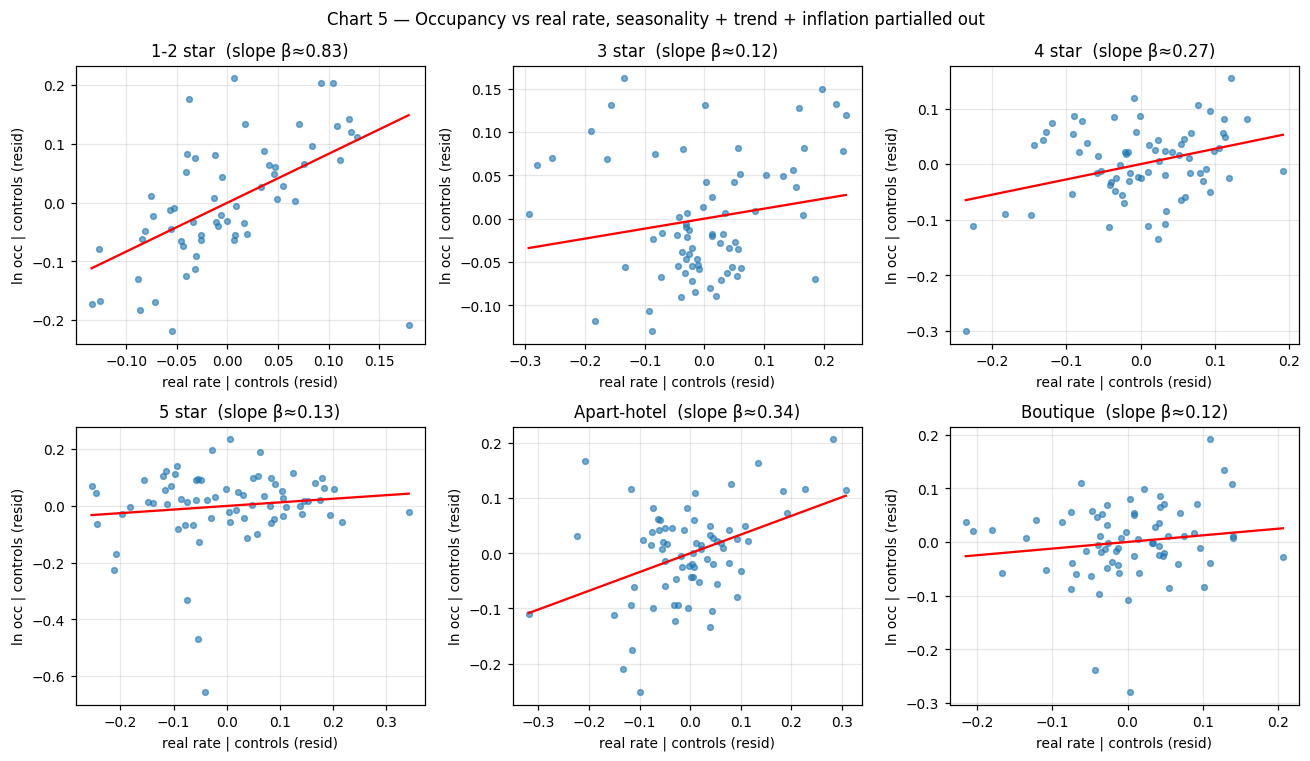

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, cat in zip(axes.ravel(), ALLc):
    s = df[df.hotel_category == cat].dropna(subset=["ln_occ", "ln_rr", "infl", "t"])
    Z = sm.add_constant(s[["infl", "t"] + MON].astype(float))
    ry = sm.OLS(s["ln_occ"], Z).fit().resid
    rx = sm.OLS(s["ln_rr"], Z).fit().resid
    ax.scatter(rx, ry, s=14, alpha=.6)
    b = np.polyfit(rx, ry, 1)[0]
    xs = np.linspace(rx.min(), rx.max(), 20)
    ax.plot(xs, b * xs, "r-")
    ax.set_title(f"{LAB[cat]}  (slope β≈{b:0.2f})")
    ax.set_xlabel("real rate | controls (resid)"); ax.set_ylabel("ln occ | controls (resid)")
fig.suptitle("Chart 5 — Occupancy vs real rate, seasonality + trend + inflation partialled out")
fig.tight_layout(); fig.savefig(C.OUT_FIG / "06_chart5_occupancy_tradeoff.png")
LOG.log("figure", "06_chart5_occupancy_tradeoff.png"); plt.show()

## All identification estimates side by side

  [06_demand] figure                 06_identification.png                      


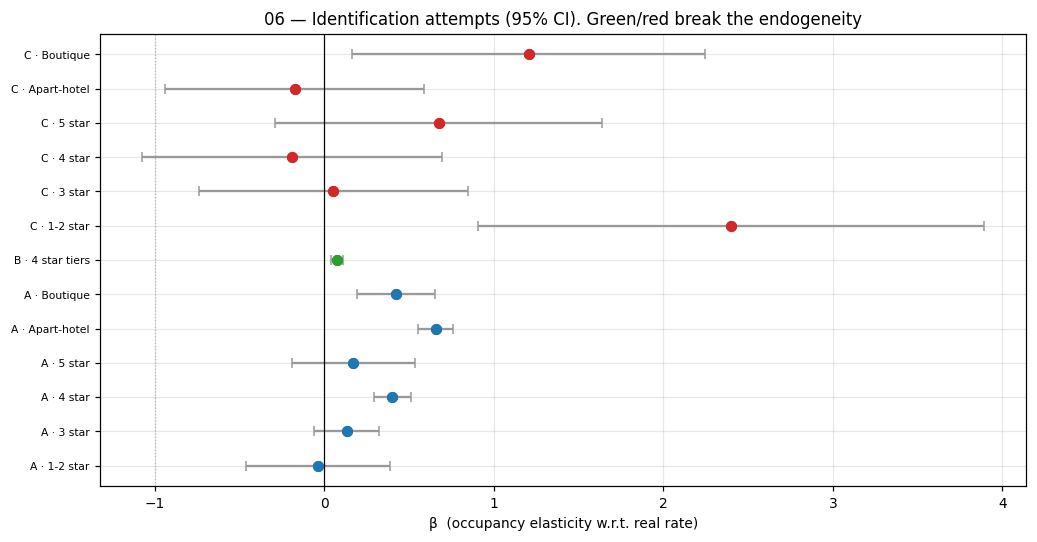

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 5))
o = summ.reset_index(drop=True)
y = np.arange(len(o))
col = {"A_yoy_diff": "tab:blue", "B_relative_price_FE": "tab:green", "C_2sls_vivienda": "tab:red"}
ax.errorbar(o["beta"], y, xerr=1.96 * o["se"], fmt="o", ecolor="0.6", color="k", capsize=3)
for i, r in o.iterrows():
    ax.scatter(r["beta"], i, color=col[r["strategy"]], s=40, zorder=3)
ax.set_yticks(y)
ax.set_yticklabels([f"{r.strategy.split('_')[0]} · {r.label}" for _, r in o.iterrows()], fontsize=7)
ax.axvline(0, color="k", lw=.8); ax.axvline(-1, color="0.7", ls=":", lw=.8)
ax.set_xlabel("β  (occupancy elasticity w.r.t. real rate)")
ax.set_title("06 — Identification attempts (95% CI). Green/red break the endogeneity")
fig.tight_layout(); fig.savefig(C.OUT_FIG / "06_identification.png")
LOG.log("figure", "06_identification.png"); plt.show()

In [9]:
LOG.flush()
print("06 complete.")

06 complete.
